--- آمارهای توصیفی برای توالی‌های تا ۱۰۰۰ اسید آمینه ---
count    382946.000000
mean        253.097003
std         162.302808
min           3.000000
25%         134.000000
50%         224.000000
75%         334.000000
max        1000.000000
Name: sequence_length, dtype: float64


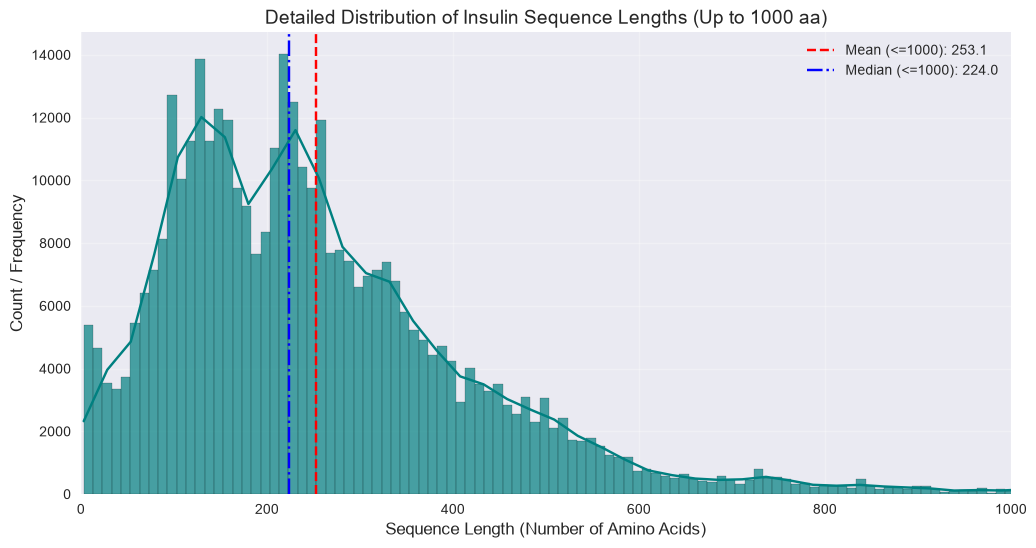

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/processed/real_proteins.csv")

df["sequence_length"] = df["seq"].str.len()

filtered_df = df[df["sequence_length"] <= 1000]

print("--- آمارهای توصیفی برای توالی‌های تا ۱۰۰۰ اسید آمینه ---")
print(filtered_df["sequence_length"].describe())

# ۴. رسم نمودار زوم‌شده روی بازه [0, 1000]
plt.figure(figsize=(12, 6))

# استفاده از binwidth=10 به این معنی است که فراوانی به تفکیک بازه‌های ۱۰تایی نمایش داده می‌شود
sns.histplot(
    data=df,  # از کل داده‌ها استفاده می‌کنیم تا فیلتر ظاهری در نمودار اعمال شود
    x="sequence_length",
    kde=True,
    binwidth=10,  # پهنای هر ستون (دقت نمودار)
    color="teal",
    alpha=0.7,
)

# محدود کردن محور X به بازه ۰ تا ۱۰۰۰
plt.xlim(0, 1000)

# اضافه کردن خطوط راهنما برای میانگین و میانه داده‌های فیلتر شده
mean_val = filtered_df["sequence_length"].mean()
median_val = filtered_df["sequence_length"].median()

plt.axvline(
    mean_val, color="red", linestyle="--", label=f"Mean (<=1000): {mean_val:.1f}"
)
plt.axvline(
    median_val,
    color="blue",
    linestyle="-.",
    label=f"Median (<=1000): {median_val:.1f}",
)

plt.title(
    "Detailed Distribution of Insulin Sequence Lengths (Up to 1000 aa)",
    fontsize=14,
)
plt.xlabel("Sequence Length (Number of Amino Acids)", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)
plt.legend()
plt.grid(axis="both", alpha=0.3)

plt.show()